# 11 — Process Estonian Soil Map (Mullakaart)

Extracts real peat/organic soil coverage per 500m grid cell from the
official Estonian Soil Map (1:10,000 scale vector dataset).

**Prerequisites:**
1. Download the soil map SHP from https://geoportaal.maaamet.ee
   (look for "Mullastiku kaart" → download SHP, ~818 MB)
2. Place in `data/raw/soil_map/` (any filename ending .shp)

**Output:** Updates `peat_overlap_pct` in features with real soil data.

In [1]:
import sys
sys.path.insert(0, "../src")

import geopandas as gpd
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

## Configuration

In [2]:
SOIL_DIR = Path("../data/raw/Mullakaart_SHP")
OUTPUT_DIR = Path("../data/processed/learned_carbon")

# Find the SHP file
shp_files = list(SOIL_DIR.rglob("*.shp")) if SOIL_DIR.exists() else []
if shp_files:
    SOIL_SHP = shp_files[0]
    print(f"Found soil map: {SOIL_SHP}")
    print(f"  Size: {SOIL_SHP.stat().st_size / 1e6:.0f} MB")
else:
    print("ERROR: No .shp file found in data/raw/soil_map/")
    print("Download from https://geoportaal.maaamet.ee (Mullastiku kaart)")
    raise FileNotFoundError("Soil map SHP not found")

Found soil map: ..\data\raw\Mullakaart_SHP\Mullakaart.shp
  Size: 1646 MB


## Load soil map and grid

In [3]:
# Load grid (500m)
grid = gpd.read_file("../data/processed/v1/base_grid.gpkg")
print(f"Grid: {len(grid)} cells")

# Load soil map (may take a minute for 818 MB)
print(f"Loading soil map from {SOIL_SHP}...")
soil = gpd.read_file(SOIL_SHP)
print(f"Soil map: {len(soil):,} polygons")
print(f"Columns: {list(soil.columns)}")

# Ensure CRS
if soil.crs != "EPSG:3301":
    soil = soil.to_crs("EPSG:3301")
if grid.crs != "EPSG:3301":
    grid = grid.to_crs("EPSG:3301")

Grid: 11224 cells
Loading soil map from ..\data\raw\Mullakaart_SHP\Mullakaart.shp...
Soil map: 766,627 polygons
Columns: ['Siffer', 'Sif1', 'Osa1', 'Sif2', 'Osa2', 'Sif3', 'Osa3', 'Sif4', 'Osa4', 'Boniteet', 'Loimis1', 'Loimis2', 'Lihtloimis', 'Huumus', 'Kivisus', 'Varv', 'Shape_Area', 'geometry']


## Identify peat soils

Estonian soil classification: peat soils have SIFFER codes starting with
specific prefixes. Common peat indicators:
- Codes with "T" prefix = turbamuld (peat soil)
- Codes with "M" = madalsoo (fen peat)
- Codes with "R" = raba (raised bog peat)

Check actual codes in the data:

In [4]:
# Explore soil type codes
if "SIFFER" in soil.columns:
    soil_col = "SIFFER"
elif "siffer" in soil.columns:
    soil_col = "siffer"
else:
    # Find the soil type column
    print("Available columns:")
    for col in soil.columns:
        if col != "geometry":
            print(f"  {col}: {soil[col].dtype}, sample: {soil[col].iloc[:3].tolist()}")
    soil_col = input("Enter soil type column name: ") if False else soil.columns[0]

print(f"\nUsing column: {soil_col}")
print(f"Unique soil types (first 30):")
types = soil[soil_col].value_counts()
for code, count in types.head(30).items():
    print(f"  {code}: {count:,}")

Available columns:
  Siffer: str, sample: ['Ag', 'Ag', 'Ag']
  Sif1: str, sample: ['Ag', 'Ag', 'Ag']
  Osa1: int32, sample: [100, 100, 100]
  Sif2: str, sample: [nan, nan, nan]
  Osa2: int32, sample: [0, 0, 0]
  Sif3: str, sample: [nan, nan, nan]
  Osa3: int32, sample: [0, 0, 0]
  Sif4: str, sample: [nan, nan, nan]
  Osa4: int32, sample: [0, 0, 0]
  Boniteet: int32, sample: [0, 0, 45]
  Loimis1: str, sample: [nan, nan, nan]
  Loimis2: str, sample: [nan, nan, nan]
  Lihtloimis: str, sample: [nan, nan, nan]
  Huumus: str, sample: [nan, nan, nan]
  Kivisus: str, sample: [nan, nan, nan]
  Varv: int32, sample: [15, 15, 15]
  Shape_Area: float64, sample: [1808.26124558, 1042.40964552, 2598.93472406]

Using column: Siffer
Unique soil types (first 30):
  Go: 39,207
  LP: 36,841
  GI: 36,045
  M’’’: 26,677
  KIg: 26,160
  LkI: 25,039
  LPg: 24,957
  Kog: 23,090
  K: 21,881
  Ko: 21,023
  Veeala, asustus või määramata: 20,454
  LkIg: 19,843
  Dg: 16,651
  Go1: 15,948
  M’’: 15,930
  LPe: 15,657


In [5]:
# Identify peat/organic soil codes
# Estonian peat soil codes typically contain: T (turvas), M (madalsoo prefix for peat fen)
# Adjust these patterns based on what you see in the data above

PEAT_CODES = []
all_codes = soil[soil_col].unique()
for code in all_codes:
    if code is None:
        continue
    code_str = str(code).strip()
    first_chars = code_str.split("(")[0].split(";")[0].split(" ")[0]  # get the main code prefix
    # Estonian soil classification - organic/peat soil types:
    # M', M'', M''' = madalsoo (fen peat)
    # S', S'', S''' = siirdesoo (transitional bog)
    # R', R'', R''' = raba (raised bog)
    # Tu, TuG, TuM = turvasmullad (peat soils)
    # Tx, Tz, Ty, Te = transitional/peat types
    is_peat = (
        code_str.startswith("M") and not code_str.startswith("Ma") or  # M', M'', M''' (fen) but not "Mal" mineral
        code_str.startswith("S'") or code_str.startswith("S''") or  # S siirdesoo
        code_str.startswith("R'") or code_str.startswith("R''") or  # R raba
        code_str.startswith("Tu") or  # turvasmullad
        code_str.startswith("Tx") or  # transitional peat
        code_str.startswith("Tz") or  # transitional peat
        code_str.startswith("Ty") or  # peat type
        code_str.startswith("Te") or  # peat type
        code_str.startswith("Tm")     # peat type
    )
    if is_peat:
        PEAT_CODES.append(code)

print(f"\nIdentified {len(PEAT_CODES)} peat soil codes:")
for code in sorted(PEAT_CODES)[:20]:
    count = (soil[soil_col] == code).sum()
    print(f"  {code}: {count:,} polygons")

# Mark peat polygons
soil["is_peat"] = soil[soil_col].isin(PEAT_CODES)
peat_polygons = soil[soil["is_peat"]]
print(f"\nTotal peat polygons: {len(peat_polygons):,} / {len(soil):,}")
print(f"Peat area: {peat_polygons.geometry.area.sum() / 1e6:.0f} km²")


Identified 364 peat soil codes:
  M: 6,777 polygons
  M(GI): 1 polygons
  M;DG: 1 polygons
  M;GI: 2 polygons
  M;GI1: 3 polygons
  M;LkG: 1 polygons
  M;M’’: 1 polygons
  MI: 3 polygons
  M\: 1 polygons
  Md: 64 polygons
  Md’’’: 1 polygons
  Meri: 452 polygons
  Mõ: 51 polygons
  M’: 15,411 polygons
  M’ Go1 Gk: 1 polygons
  M’ LG Go: 1 polygons
  M’ M’’ GI1: 3 polygons
  M’(1): 1 polygons
  M’(1)al: 1 polygons
  M’(3)al: 1 polygons

Total peat polygons: 72,504 / 766,627
Peat area: 11839 km²


## Clip to Lääne County

In [6]:
# Clip soil to county extent (much faster overlay)
county_bounds = grid.total_bounds  # minx, miny, maxx, maxy
from shapely.geometry import box as shapely_box
county_box = gpd.GeoDataFrame(
    geometry=[shapely_box(*county_bounds)], crs="EPSG:3301"
)

print("Clipping soil map to county extent...")
soil_clipped = gpd.clip(soil, county_box)
print(f"Clipped: {len(soil_clipped):,} polygons (from {len(soil):,})")

peat_clipped = soil_clipped[soil_clipped["is_peat"]]
print(f"Peat in county: {len(peat_clipped):,} polygons")

Clipping soil map to county extent...
Clipped: 34,566 polygons (from 766,627)
Peat in county: 2,039 polygons


## Overlay with grid — compute peat fraction per cell

In [7]:
print("Computing peat overlap per grid cell...")

# Overlay peat polygons with grid
if len(peat_clipped) > 0:
    # Fix mixed geometry types (explode multipolygons, drop non-polygons)
    peat_clipped = peat_clipped.explode(index_parts=False)
    peat_clipped = peat_clipped[peat_clipped.geometry.type == "Polygon"]
    print(f"  Peat polygons after cleanup: {len(peat_clipped):,}")

    peat_overlay = gpd.overlay(
        grid[["cell_id", "geometry"]],
        peat_clipped[["geometry", "is_peat"]],
        how="intersection",
    )
    peat_overlay["peat_area"] = peat_overlay.geometry.area

    # Sum peat area per cell
    peat_per_cell = peat_overlay.groupby("cell_id")["peat_area"].sum().reset_index()

    # Use LAND area as denominator (exclude water portion of coastal cells)
    # Load water_pct from the 500m features
    v1_path = Path("../data/processed/v1/features_v1.parquet")
    if v1_path.exists() and "water_pct" in pd.read_parquet(v1_path, columns=None).columns:
        v1 = pd.read_parquet(v1_path, columns=["cell_id", "water_pct"])
        water_map = v1.set_index("cell_id")["water_pct"]
    else:
        # No water data available — use total area
        water_map = pd.Series(0, index=grid["cell_id"])

    cell_total_areas = grid.set_index("cell_id").geometry.area
    # Land area = total area × (1 - water fraction)
    water_for_cells = cell_total_areas.index.map(lambda cid: water_map.get(cid, 0))
    land_areas = cell_total_areas * (1 - water_for_cells)
    land_areas = land_areas.clip(lower=1.0)  # avoid div by zero

    # Compute peat fraction relative to LAND area
    peat_per_cell["peat_overlap_pct"] = (
        peat_per_cell["peat_area"] / peat_per_cell["cell_id"].map(land_areas)
    ).clip(0, 1)

    print(f"Cells with peat: {len(peat_per_cell)} / {len(grid)}")
    print(f"Mean peat fraction (where present): {peat_per_cell['peat_overlap_pct'].mean():.3f}")
else:
    peat_per_cell = pd.DataFrame({"cell_id": [], "peat_overlap_pct": []})
    print("No peat polygons found in county!")

Computing peat overlap per grid cell...
  Peat polygons after cleanup: 2,049
Cells with peat: 4998 / 11224
Mean peat fraction (where present): 0.529


C:\Users\risto\projects\et-landuse-neuroevolution\.venv\Lib\site-packages\geopandas\tools\overlay.py:358: UserWarning: `keep_geom_type=True` in overlay resulted in 625 dropped geometries of different geometry types than df1 has. Set `keep_geom_type=False` to retain all geometries
  result = _collection_extract(result, geom_type, keep_geom_type_warning)


## Save and update features

In [8]:
# Save peat data
peat_output = grid[["cell_id"]].merge(
    peat_per_cell[["cell_id", "peat_overlap_pct"]], on="cell_id", how="left"
)
peat_output["peat_overlap_pct"] = peat_output["peat_overlap_pct"].fillna(0)

peat_output.to_parquet(OUTPUT_DIR / "soil_peat_real.parquet", index=False)
print(f"Saved: {OUTPUT_DIR / 'soil_peat_real.parquet'}")
print(f"  Cells with peat > 0: {(peat_output['peat_overlap_pct'] > 0).sum()}")
print(f"  Cells with peat > 0.3: {(peat_output['peat_overlap_pct'] > 0.3).sum()}")
print(f"  Mean peat (all cells): {peat_output['peat_overlap_pct'].mean():.4f}")

# Update features_with_forest.parquet
features_path = OUTPUT_DIR / "features_with_forest.parquet"
if features_path.exists():
    features = pd.read_parquet(features_path)
    # Replace proxy with real peat data
    if "peat_overlap_pct" in features.columns:
        features = features.drop(columns=["peat_overlap_pct"])
    features = features.merge(peat_output[["cell_id", "peat_overlap_pct"]], on="cell_id", how="left")
    features["peat_overlap_pct"] = features["peat_overlap_pct"].fillna(0)
    features.to_parquet(features_path, index=False)
    print(f"\nUpdated {features_path}")

Saved: ..\data\processed\learned_carbon\soil_peat_real.parquet
  Cells with peat > 0: 4998
  Cells with peat > 0.3: 3029
  Mean peat (all cells): 0.2356

Updated ..\data\processed\learned_carbon\features_with_forest.parquet


## Visualize

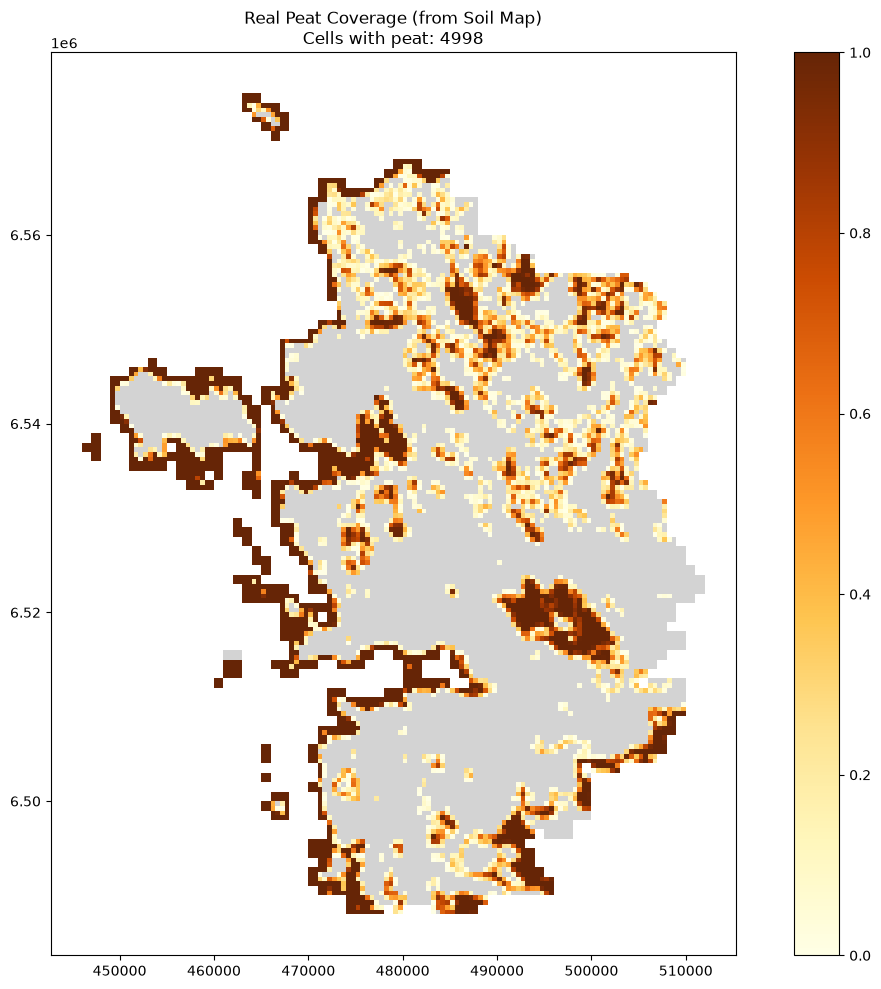

In [9]:
fig, ax = plt.subplots(figsize=(12, 10))
import matplotlib.pyplot as plt

map_df = grid.merge(peat_output[["cell_id", "peat_overlap_pct"]], on="cell_id")
grid.plot(ax=ax, color="lightgrey", edgecolor="none")
map_df[map_df["peat_overlap_pct"] > 0].plot(
    column="peat_overlap_pct", ax=ax, legend=True, cmap="YlOrBr",
    vmin=0, vmax=1
)
ax.set_title(f"Real Peat Coverage (from Soil Map)\n"
             f"Cells with peat: {(peat_output['peat_overlap_pct'] > 0).sum()}")
plt.tight_layout()
plt.show()

## Next steps

Re-run notebook 09 or 10 — the updated `features_with_forest.parquet`
now has real peat data. Wetland restoration should become viable
in cells with high peat coverage.